# Fase 2 — Limpieza e ingeniería de datos

| Campo | Valor |
|---|---|
| **Rol líder** | Ingeniero de Datos |
| **Persona encargada** | Mateo Del Giudice |
| **Entrada** | `data/raw/chembl_panama_bioactivity_raw.csv` |
| **Salida** | `activities_clean.csv` + `compounds_all.csv` (151) + `compounds_features.csv` (94) |

## Qué hace esta fase
Limpiar y consolidar la bioactividad cruda de ChEMBL en tablas listas para análisis:
- **Deduplicar** filas marcadas como `potential_duplicate` y diagnosticar valores faltantes.
- **Imputar** descriptores estructurales por mediana de familia (sin inventar pChEMBL).
- **Generar** `activities_clean.csv` (nivel medición) y `compounds_features.csv` / `compounds_all.csv` (nivel compuesto).


## 0. Configuración

**Descripción:** Importar el preprocesador ChEMBL, fijar rutas de entrada/salida y cargar el CSV crudo de bioactividad para inspeccionar tamaño y duplicados potenciales.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

import _bootstrap
from src.paths import PROJECT_ROOT as ROOT, setup_path
setup_path()

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 120})

FIG_DIR = ROOT / "outputs" / "chembl" / "figures"
RESULTS_DIR = ROOT / "outputs" / "chembl" / "results"
for d in (FIG_DIR, RESULTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

from src.analisis_proyecto.preprocessing.pipeline import (
    ChemblPreprocessor,
    load_bioactivity,
    missingness_upset_series,
    pchembl_imputation_report,
    plot_missingno_report,
)

RAW_CSV = ROOT / "data" / "raw" / "chembl_panama_bioactivity_raw.csv"
if not RAW_CSV.exists():
    RAW_CSV = ROOT / "data" / "raw" / "chembl_panama_bioactivity.csv"
ACTIVITIES_CSV = ROOT / "data" / "processed" / "activities_clean.csv"
COMPOUNDS_ALL_CSV = ROOT / "data" / "processed" / "compounds_all.csv"
COMPOUNDS_CSV = ROOT / "data" / "processed" / "compounds_features.csv"
NAN_COL_THRESHOLD = 250

assert RAW_CSV.exists(), f"No se encontró {RAW_CSV}. Ejecuta fase1_adquisicion.ipynb"

raw = load_bioactivity(RAW_CSV)
print(f"RAW: {raw.shape[0]:,} filas x {raw.shape[1]} columnas | compuestos: {raw['chembl_id'].nunique()}")
if "potential_duplicate" in raw.columns:
    n_dup = int((raw["potential_duplicate"].fillna(0).astype(int) == 1).sum())
    print(f"Filas potential_duplicate=1 (a eliminar): {n_dup}")


RAW: 11,091 filas x 36 columnas | compuestos: 151
Filas potential_duplicate=1 (a eliminar): 996


**Conclusión:** El RAW arranca con miles de filas y cientos de `potential_duplicate=1`. Esos duplicados deben eliminarse antes de cualquier agregación a nivel compuesto; si no, se inflan conteos y se sesgan medianas.


## 1. Diagnóstico de faltantes

**Descripción:** Generar el reporte missingno (matriz, barras, heatmap) y un UpSet de patrones de NaN sobre el RAW **antes** del dedup, para documentar el estado inicial.


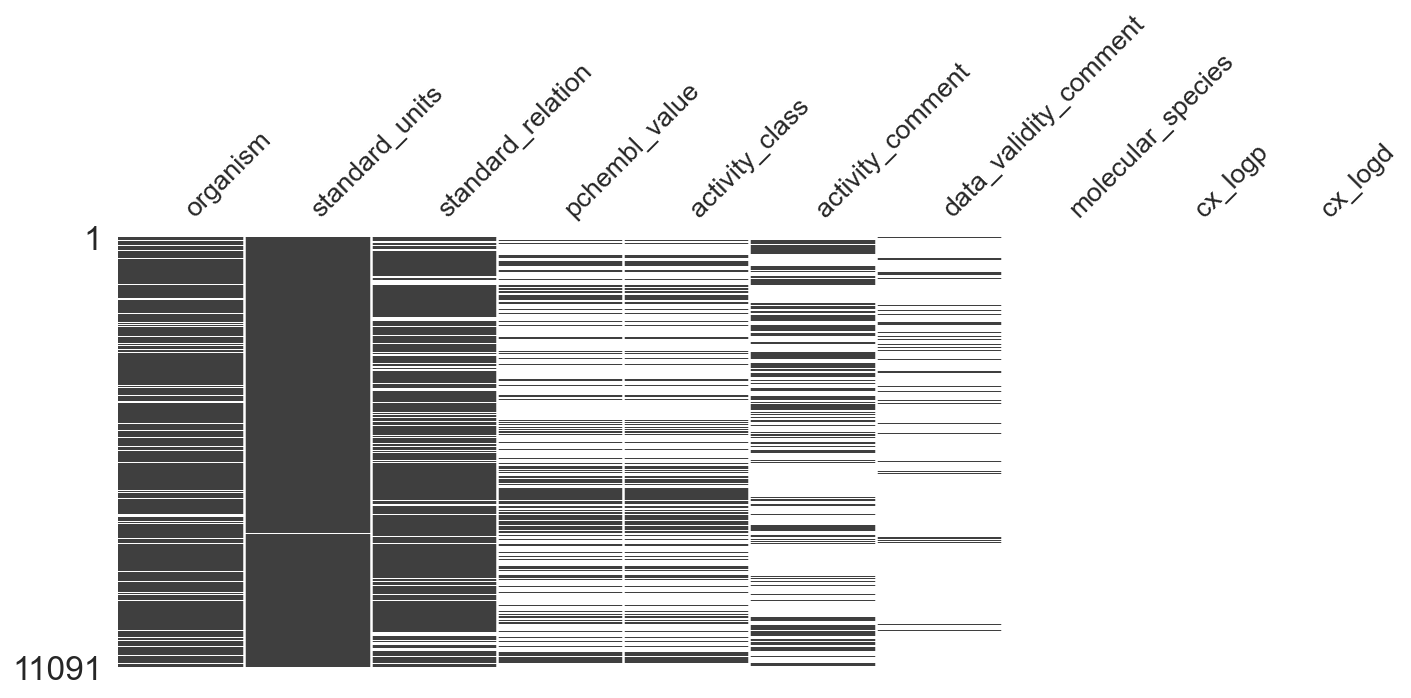

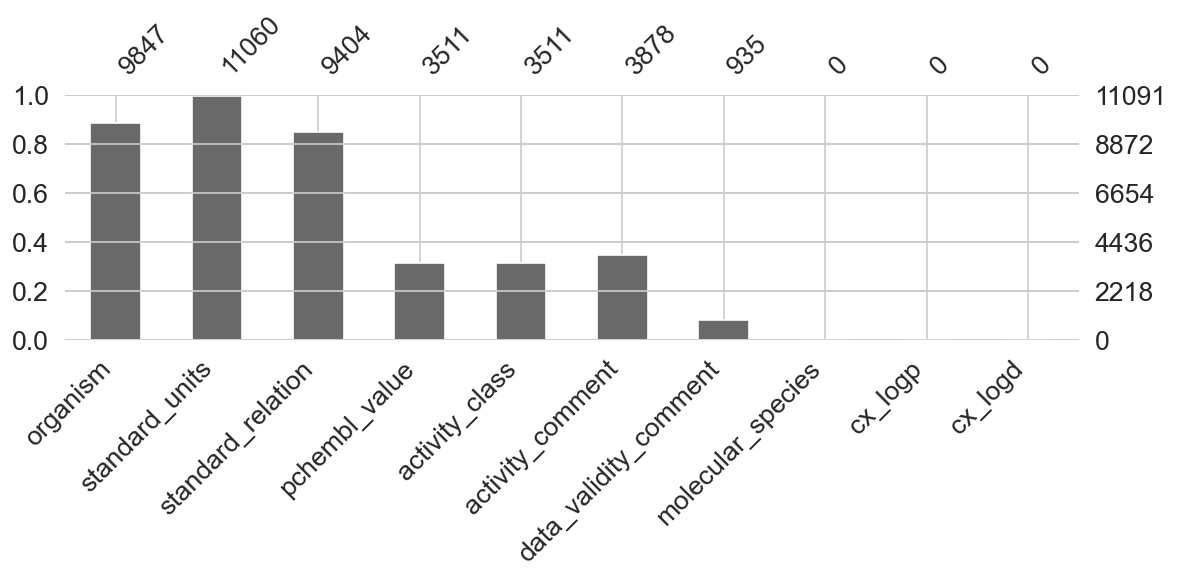

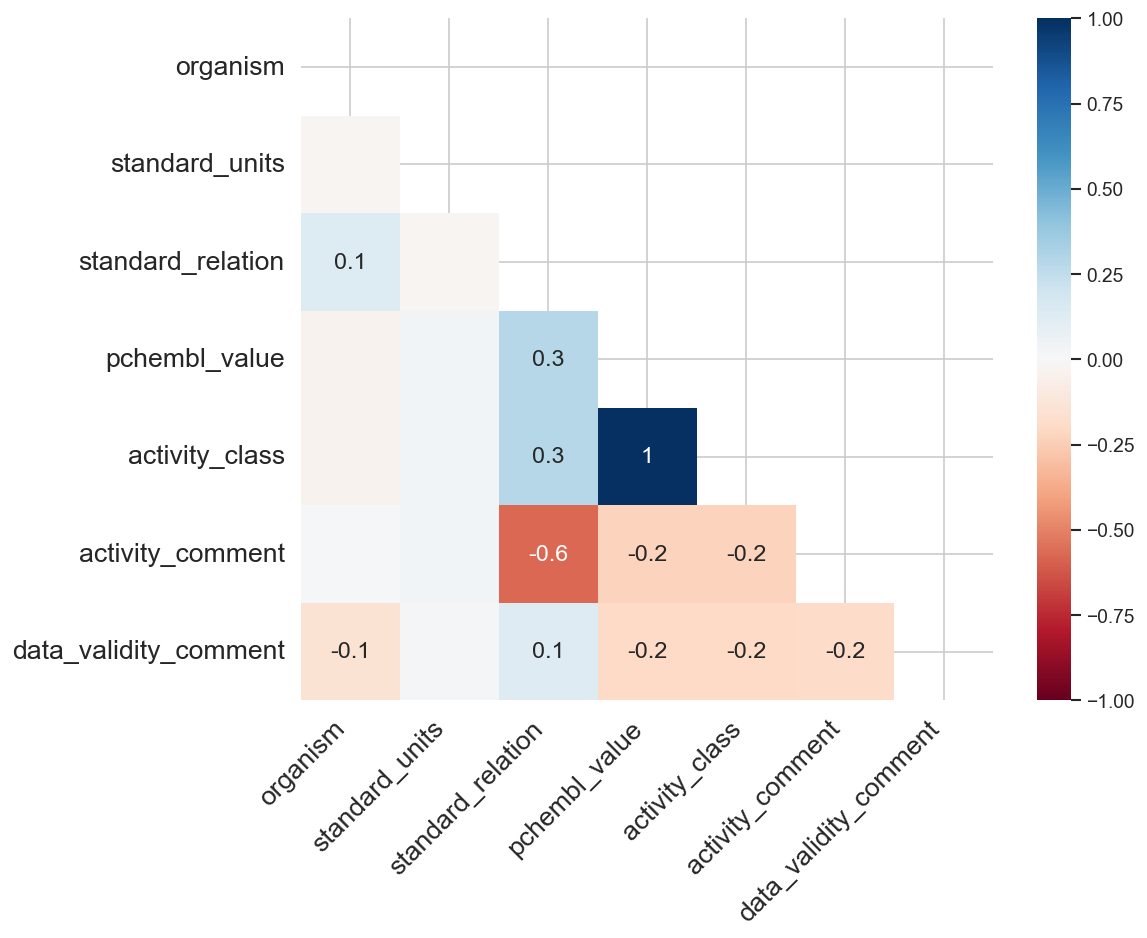

c:\Users\mateo\Desktop\PROYECTOS\JIC2026\.venv\lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
c:\Users\mateo\Desktop\PROYECTOS\JIC2026\.venv\lib\site-packages\upsetplot\plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are sett

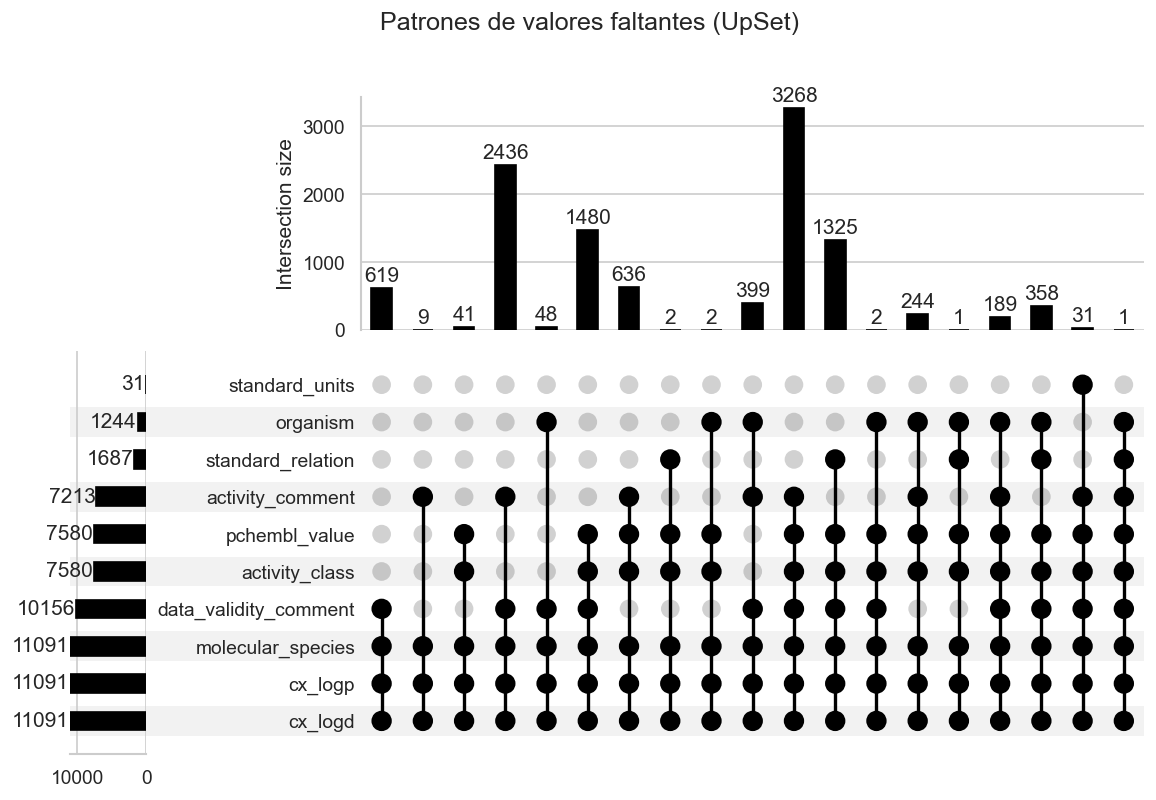

In [2]:
saved_msno = plot_missingno_report(raw, FIG_DIR)
if saved_msno:
    for path in saved_msno:
        display(Image(filename=str(path)))

upset_data, nan_cols = missingness_upset_series(raw)
if upset_data is not None:
    from upsetplot import UpSet
    upset = UpSet(upset_data, subset_size="count", show_counts=True)
    upset.plot()
    plt.suptitle("Patrones de valores faltantes (UpSet)")
    plt.savefig(FIG_DIR / "missingness_upset.png", bbox_inches="tight")
    plt.show()


**Conclusión:** Los faltantes no son aleatorios: se concentran en columnas de actividad/potencia y en campos opcionales de target. El diagnóstico justifica (a) dropear columnas casi vacías y (b) imputar solo descriptores estructurales por mediana de familia, sin inventar pChEMBL.


## 2. Dedup + imputación + tablas de salida

**Descripción:** Ejecutar el pipeline completo: eliminar duplicados, dropear columnas con >250 NaN, imputar descriptores por mediana de familia, guardar `activities_clean.csv`, `compounds_all.csv` y `compounds_features.csv`, y exportar embudo + reporte de censura.


In [3]:
import json

pre = ChemblPreprocessor(nan_threshold=NAN_COL_THRESHOLD)
activities = pre.clean_activities(raw)

ACTIVITIES_CSV.parent.mkdir(parents=True, exist_ok=True)
activities.to_csv(ACTIVITIES_CSV, index=False)

compounds_all = pre.build_compounds_all(activities)
compounds = pre.build_compound_features(activities)
assert compounds_all["chembl_id"].nunique() == len(compounds_all)
compounds_all.to_csv(COMPOUNDS_ALL_CSV, index=False)
compounds.to_csv(COMPOUNDS_CSV, index=False)

funnel = pre.corpus_funnel(activities, compounds_all, compounds)
censoring = pre.censoring_report(activities)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / "corpus_funnel.json").write_text(json.dumps(funnel, indent=2), encoding="utf-8")
(RESULTS_DIR / "censoring_report.json").write_text(json.dumps(censoring, indent=2), encoding="utf-8")

print(f"activities: {activities.shape} | structural: {compounds_all.shape} | potency: {compounds.shape}")
print(f"Embudo: {funnel['raw_compounds']} -> {funnel['with_potency_binding_min_support']} (sesgo al alza en potencia)")
print(pchembl_imputation_report(activities))

if "is_censored" in activities.columns:
    print(f"Censuradas: {int(activities['is_censored'].sum())} filas ({censoring['pct_censored']}%)")
if "standard_relation" in activities.columns:
    rel = activities["standard_relation"].value_counts(dropna=False)
    print("\nCensura / relacion standard_relation (conservada en activities_clean):")
    display(rel.to_frame("n"))


  Duplicados eliminados: 996
activities: (10095, 31) | structural: (151, 15) | potency: (94, 26)
Embudo: 151 -> 94 (sesgo al alza en potencia)
{'n_total': 10095, 'n_imputed': 0, 'n_original': 10095, 'pct_imputed': 0.0}
Censuradas: 3685 filas (36.5%)

Censura / relacion standard_relation (conservada en activities_clean):


,n
standard_relation,
=,8097
>,1914
<,73
>=,6
~,2
<=,2
>>,1


**Conclusión:** Tras limpiar, quedan mediciones sin duplicados, compuestos estructurales y un subconjunto con potencia (embudo con **sesgo al alza**). La imputación de pChEMBL es 0% (no se inventan potencias). ~37% de filas siguen censuradas y se conservan con `standard_relation` para análisis posteriores. Listo para Fase 3 (EDA).
